### Methods for reading HDF5 files and exporting to dictionary structure.

In [410]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import re

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from IPython.display import display as ipydisplay

# Threshold for peak-to-average ratio acceptance of image.
THRESHOLD = 10


def h5_to_dict(filename):
    """Read an HDF5 file into a nested dict.

    Structure:
        data[group_name]['attrs']        -> group attributes (metadata)
        data[group_name][dataset_name]   -> dict with 'data' (numpy array)
                                           and 'attrs' (dataset attributes)
    """
    def _read_group(grp):
        out = {'attrs': dict(grp.attrs)}
        for name, item in grp.items():
            if isinstance(item, h5py.Dataset):
                out[name] = {'data': item[()], 'attrs': dict(item.attrs)}
            elif isinstance(item, h5py.Group):
                out[name] = _read_group(item)
        return out

    with h5py.File(filename, 'r') as f:
        return {key: _read_group(f[key]) for key in f}


def data_from_h5_files(files):
    """Read multiple HDF5 files into a nested dict."""
    data = {}
    for filename in files:
        key = re.sub('pass', '',
                     os.path.basename(filename).split('_')[2].split('-')[0])
        data[key] = h5_to_dict(filename)
    return data


def files_in_directory(wdir, pattern):
    """List files in a directory matching a regex pattern."""
    rawfiles = os.listdir(wdir)
    return sorted([f"{wdir}/{f}" for f in rawfiles if re.match(pattern, f)])


def beam_visible(img, cx, cy, droi=4, threshold=THRESHOLD):
    """Detect if a beam is present based on the peak-to-average ratio.

    Args:
        img (np.array): The 2D image array to analyze.
        cx (int): The x-coordinate of the beam centroid.
        cy (int): The y-coordinate of the beam centroid.
        droi (int): The half-size of the region around the centroid used
            to calculate the peak intensity. Default is 4 pixels.
        threshold (float): The minimum peak-to-average ratio required to
            consider the beam visible. Default is 10.

    Returns:
        bool: True if the beam is considered visible, False otherwise.
    """
    roi_avg = np.mean(img[cy-droi:cy+droi, cx-droi:cx+droi])
    mean = np.mean(img)
    ratio_rtom = roi_avg / mean if mean != 0 else 0

    return ratio_rtom >= threshold


def beam_properties(dataset, dev_motor, droi=4, threshold=THRESHOLD):
    """Return properties of the beam profiles from the data dict.

    Args:
        dataset (dict): Nested dict containing the set of one full scan.
        dev_motor (str): The device and motor being scanned (e.g., 'sample.x').
        droi (int): The half-size of the region around the centroid used to
            determine if the beam is visible. Default is 4 pixels.
        threshold (float): The minimum peak-to-average ratio required to
            consider the beam visible. Default is 10.

    Returns:
        beam_propties : A dict mapping scan numbers to (cx, cy), (fx, fy)
            centroids and FWHMs.
        beam_images   : A dict mapping scan numbers to DVF images of the beam,
            only scans where the beam is visible are returned.
    """
    beam_propties = {}
    beam_images   = {}
    xval          = []
    for scan, scandata in dataset.items():
        # Extract scanning index and observable value.
        sc = int(scan.split('-')[-1])
        xval = float(scandata['attrs'].get(dev_motor)[0])

        # Get image data and calculate centroid.
        img = scandata['dvf_B1']['data']

        # Centroids.
        # cx = np.sum(img, axis=0).argmax()
        # cy = np.sum(img, axis=1).argmax()
        cx_sum = np.sum(img, axis=0)
        cy_sum = np.sum(img, axis=1)

        # DEBUG
        xsmooth = savgol_filter(cx_sum, window_length=21, polyorder=2)
        ysmooth = savgol_filter(cy_sum, window_length=21, polyorder=2)

        xmaxraw = np.argmax(cx_sum)
        ymaxraw = np.argmax(cy_sum)
        cx = np.argmax(xsmooth)
        cy = np.argmax(ysmooth)
        print(f">>>>> Scan {sc}: Centroid raw at (cx={xmaxraw},"
              f" cy={ymaxraw}), ")
        print(f">>>>> Scan {sc}: Centroid at (cx={cx}, cy={cy}), ")
        # DEBUG

        # FWHMs
        x_profile = img[cy, :]
        y_profile = img[:, cx]

        fwhm_x = np.sum(x_profile > (x_profile.max() / 2))
        fwhm_y = np.sum(y_profile > (y_profile.max() / 2))

        # Do not register properties if there is no beam image.
        if not beam_visible(img, cx, cy, droi, threshold):
            continue

        # Dict is indexed by scan number.
        beam_propties[sc] = [xval, [cx, cy], [fwhm_x, fwhm_y]]
        beam_images[sc]   = img
 
    return beam_images, beam_propties


def beam_centroid(dataset, dev_motor, droi=4, threshold=THRESHOLD):
    """Return centroids of the beam profiles from the data dict.

    Args:
        dataset (dict): Nested dict containing the set of one full scan.
        dev_motor (str): The device and motor being scanned (e.g., 'sample.x').
        droi (int): The half-size of the region around the centroid used to
            determine if the beam is visible. Default is 4 pixels.
        threshold (float): The minimum peak-to-average ratio required to
            consider the beam visible. Default is 10.

    Returns:
        dict: A dict mapping scan numbers to (cx, cy) centroids.
    """
    centroids = {}
    xval      = []

    _, beam_propties = beam_properties(dataset, dev_motor, droi, threshold)

    for sc in beam_propties.keys():
        xval   = beam_propties[sc][0]
        cx, cy = beam_propties[sc][1]

        centroids[sc] = [xval, [cx, cy]]
 
    return centroids


def beam_fwhm(dataset, dev_motor, droi=4, threshold=THRESHOLD):
    """Return fwhm of the beam profiles from the data dict.

    Args:
        dataset (dict): Nested dict containing the set of one full scan
            (one pass).
        dev_motor (str): The device and motor being scanned (e.g., 'sample.x').
        droi (int): The half-size of the region around the centroid used to
            determine if the beam is visible. Default is 4 pixels.
        threshold (float): The minimum peak-to-average ratio required to
            consider the beam visible. Default is 10.

    Returns:
        dict: A dict mapping scan numbers to (fx, fy) fwhm's.
    """
    fwhms = {}
    _, beam_propties = beam_properties(dataset, dev_motor, droi, threshold)

    for sc in beam_propties.keys():
        xval   = beam_propties[sc][0]
        fx, fy = beam_propties[sc][2]

        fwhms[sc] = [xval, [fx, fy]]

    return fwhms


def beam_intensity(dataset, dev_motor, droi=4, threshold=THRESHOLD):
    """Return the total intensity of the beam profiles from the data dict.

    Args:
        dataset (dict): Nested dict containing the set of one full scan
            (one pass).
        dev_motor (str): The device and motor being scanned (e.g., 'sample.x').
        droi (int): The half-size of the region around the centroid used to
            determine if the beam is visible. Default is 4 pixels.
        threshold (float): The minimum peak-to-average ratio required to
            consider the beam visible. Default is 10.

    Returns:
        dict: A dict mapping scan numbers to total intensity.
    """
    beam_images, beam_propties = beam_properties(dataset, dev_motor,
                                                 droi, threshold)
    exptime = dataset['scan-0000']['dvf_B1']['attrs']['expo_time']

    intensities = {}
    droi = 2
    for sc in beam_images.keys():
        img            = beam_images[sc]
        xval           = beam_propties[sc][0]
        cx, cy         = beam_propties[sc][1]
        fwhm_x, fwhm_y = beam_propties[sc][2]

        peak = np.mean(img[cy - droi : cy + droi + 1,
                           cx - droi : cx + droi + 1])

        mask = img > (peak / 2)
        area_mask  = np.sum(mask)
        img_masked = np.where(mask, img, 0)
        area_img_masked = np.sum(img_masked)

        intensity_by_mask = (area_img_masked / (area_mask * exptime)
                             if area_mask != 0 else 0)

        peak /= exptime
        peak_fwhm_norm = (peak / (fwhm_x * fwhm_y)
                          if fwhm_x * fwhm_y != 0 else 0)

        intensities[sc] = [xval, [peak, intensity_by_mask, peak_fwhm_norm]]

    return intensities


def observable_data(dataset, observable):
    """Extract the behavior of a variable across scans in a dataset.

    Args:
        dataset (dict): Nested dict containing the set of
            one full scan (one pass).
        observable (str): The variable to extract
            (e.g., 'photocollector', 'centroid').

    Returns:
        tuple: (motor, scans, xval, yval) where:
            motor (str)      : The name of the scanned variable.
            scans (np.array) : Array of scan numbers.
            xval (np.array)  : Array of scanned variable values.
            yval (list of np.array): List of arrays containing the observable
                values for each scan.
    """
    # The scanned variable (idx).
    motor     = dataset['scan-0000']['attrs']['scan_motor']
    device    = dataset['scan-0000']['attrs']['scan_type']
    dev_motor = f"{device}.{motor}"

    # Centroids are calculated in beam_centroid().
    if observable == 'centroid':
        centroids = beam_centroid(dataset, dev_motor)

        # Dict is ordered by scan number.
        scans = np.array(list(centroids.keys()))

        # Observable values.
        xvals = np.array([centroids[sc][0] for sc in scans])

        # Cetroid values.
        values = np.array([centroids[sc][1] for sc in scans])
        centr  = [values[:, 0], values[:, 1]]

        return motor, scans, xvals, centr

    # FWHMs are calculated in beam_fwhm().
    if observable == 'fwhm':
        fwhms = beam_fwhm(dataset, dev_motor)

        # Dict is ordered by scan number.
        scans = np.array(list(fwhms.keys()))

        # Observable values.
        xvals = np.array([fwhms[sc][0] for sc in scans])

        # Cetroid values.
        values = np.array([fwhms[sc][1] for sc in scans])
        fs     = [values[:, 0], values[:, 1]]

        return motor, scans, xvals, fs

    # Intensities are calculated in beam_intensity().
    if observable == 'intensity':
        intensities = beam_intensity(dataset, dev_motor)

        # Dict is ordered by scan number.
        scans = np.array(list(intensities.keys()))

        # Observable values.
        xvals = np.array([intensities[sc][0] for sc in scans])

        # Cetroid values.
        values      = np.array([intensities[sc][1] for sc in scans])
        intensities = [values[:, 0], values[:, 1], values[:, 2]]

        return motor, scans, xvals, intensities

    scans, xval, yval = [], [], []
    # Run over each point scanned.
    for scan, scandata in dataset.items():
        # Get scan number, scanning index and observable value.
        scans.append(int(scan.split('-')[-1]))
        xmeta = scandata['attrs'].get(dev_motor)
        ymeta = scandata['attrs'].get(f"{device}.{observable}")

        # Append the values, handling both scalar and array metadata cases.
        if isinstance(xmeta, list) or isinstance(xmeta, np.ndarray):
            xval.append(float(xmeta[0]))
        else:
            xval.append(float(xmeta))
        if isinstance(ymeta, list) or isinstance(ymeta, np.ndarray):
            yval.append(float(ymeta[0]))
        else:
            yval.append(float(ymeta))

    return motor, np.array(scans), np.array(xval), [np.array(yval)]


def scan_plot(data, observable, first_item=0, last_item=None,
              gr=1, labels=None):
    """Plot the behavior of an observable across scans for each dataset.

    Args:
        data (dict): Nested dict containing the set of all passes.
        observable (str): The variable to plot (e.g., 'photocollector',
            'centroid').
        first_item (int): The first point of the scan to be included in
            the plot. It allows skipping initial points if desired.
            Default is 0 (include all points).
        last_item (int or None): The last point of the scan to be included
            in the plot. If None, include all points.
        gr (int): The number of subplots to create. Default is 1.
        labels (list of str or None): Custom labels for each subplot.
            Default is None.
    """
    if gr == 1:
        fig, ax = plt.subplots(figsize=(15, 6))
        ax = [ax]
    else:
        fig, ax = plt.subplots(nrows=1, ncols=gr, figsize=(20, 6))

    # Loop over each dataset and plot the observable vs. scan number.
    # Each dataset corresponds to a different pass.
    for datakey, dataset in data.items():
        motor, scans, xval, yvals = observable_data(dataset, observable)

        for idx, yval in enumerate(yvals):
            if last_item is None:
                ax[idx].plot(xval[first_item:], yval[first_item:],
                        marker='o', label=f'Dataset {datakey}')
            else:
                ax[idx].plot(xval[first_item:last_item],
                             yval[first_item:last_item],
                             marker='o', label=f'Dataset {datakey}')

    # Graph appearance settings.
    for idx in range(gr):
        ax[idx].set_xlabel(motor.capitalize())
        ax[idx].set_ylabel(f"{observable.capitalize()}"
                           f" {labels[idx] if labels else ''}")
        ax[idx].legend()
        ax[idx].grid()

    plt.show()


def centroid_plot(dataset, scanpass, wdir='.', save_fmt='gif'):
    """Plot the beam profile images and their centroids in a dataset.

    Args:
        dataset (dict): Nested dict containing the set of one full scan
            (one pass).
        scanpass (str): Identifier for the scan pass
            (used in titles and filenames).
        wdir (str): Working directory to save the plots.
            Default is current directory.
        save_fmt (str): Format to save the animation
            ('gif', 'mp4', or '' to skip saving).
    """
    # Use the existing function to get motor, positions and centroids.
    (motor, scan_nums, xval,
     (cx_all, cy_all)) = observable_data(dataset, 'centroid')

    # Retrieve images in the same order as scan_nums.
    images = [(f'scan-{sc:04d}',
            dataset[f'scan-{sc:04d}']['dvf_B1']['data'])
            for sc in scan_nums]

    fig, (ax_img, ax_cx, ax_cy) = plt.subplots(1, 3, figsize=(24, 5))

    # Left: image
    im = ax_img.imshow(images[0][1], cmap='viridis', animated=True)
    plt.colorbar(im, ax=ax_img, label='Intensity')
    ax_img.set_xlabel('Pixel X')
    ax_img.set_ylabel('Pixel Y')
    img_title = ax_img.set_title('')

    # Center: centroid X trace with a moving marker
    ax_cx.plot(xval, cx_all, marker='o',
            color='steelblue', label='Centroid X')
    marker_pt, = ax_cx.plot([], [], 'ro',
                            markersize=10, label='Current')
    ax_cx.set_xlabel(motor.capitalize())
    ax_cx.set_ylabel('Centroid X (px)')
    ax_cx.set_title('Centroid X')
    ax_cx.legend()
    ax_cx.grid(True)

    # Right: centroid Y trace with a moving marker
    ax_cy.plot(xval, cy_all, marker='o',
               color='orange', label='Centroid Y')
    marker_pt_y, = ax_cy.plot([], [], 'ro',
                              markersize=10, label='Current')
    ax_cy.set_xlabel(motor.capitalize())
    ax_cy.set_ylabel('Centroid Y (px)')
    ax_cy.set_title('Centroid Y')
    ax_cy.legend()
    ax_cy.grid(True)

    def update(frame):
        name, img = images[frame]
        im.set_data(img)
        im.set_clim(img.min(), img.max())
        img_title.set_text(f'Scan: {name}')
        marker_pt.set_data([xval[frame]], [cx_all[frame]])
        marker_pt_y.set_data([xval[frame]], [cy_all[frame]])
        return im, img_title, marker_pt, marker_pt_y

    anim = FuncAnimation(fig, update, frames=len(images),
                         interval=300, blit=True)
    plt.tight_layout(pad=3.0)

    if save_fmt == 'gif':
        anim.save(f'{wdir}/beam_xy_pass_{scanpass}.gif',
                writer='pillow', fps=2, dpi=300)
    elif save_fmt == 'mp4':
        # Alternatively, save as mp4 (requires ffmpeg):
        anim.save(f'{wdir}/beam_xy_pass_{scanpass}.mp4',
                writer='ffmpeg', fps=2, dpi=300)
    else:
        print("File format not specified or unknown"
              " (use 'gif' or 'mp4' to save to file)."
              " Skipping saving process.")
        pass

    plt.close()
    ipydisplay(HTML(anim.to_jshtml()))


def fwhm_plot(dataset, scanpass, wdir='.', save_fmt='gif'):
    """Plot the beam profile images and their FWHMs in a dataset.

    Args:
        dataset (dict): Nested dict containing the set of one full scan
            (one pass).
        scanpass (str): Identifier for the scan pass
            (used in titles and filenames).
        wdir (str): Working directory to save the plots.
            Default is current directory.
        save_fmt (str): Format to save the animation
            ('gif', 'mp4', or '' to skip saving).
    """
    # Use the existing function to get motor, positions and centroids.
    (motor, scan_nums, xval,
     (fx_all, fy_all)) = observable_data(dataset, 'fwhm')

    # Retrieve images in the same order as scan_nums.
    images = [(f'scan-{sc:04d}',
            dataset[f'scan-{sc:04d}']['dvf_B1']['data'])
            for sc in scan_nums]

    fig, (ax_img, ax_fx, ax_fy) = plt.subplots(1, 3, figsize=(24, 5))

    # Left: image
    im = ax_img.imshow(images[0][1], cmap='viridis', animated=True)
    plt.colorbar(im, ax=ax_img, label='Intensity')
    ax_img.set_xlabel('Pixel X')
    ax_img.set_ylabel('Pixel Y')
    img_title = ax_img.set_title('')

    # Center: centroid X trace with a moving marker
    ax_fx.plot(xval, fx_all, marker='o',
            color='steelblue', label='FWHM X')
    marker_pt, = ax_fx.plot([], [], 'ro',
                            markersize=10, label='Current')
    ax_fx.set_xlabel(motor.capitalize())
    ax_fx.set_ylabel('FWHM X (px)')
    ax_fx.set_title('FWHM X')
    ax_fx.legend()
    ax_fx.grid(True)

    # Right: centroid Y trace with a moving marker
    ax_fy.plot(xval, fy_all, marker='o',
               color='orange', label='FWHM Y')
    marker_pt_y, = ax_fy.plot([], [], 'ro',
                              markersize=10, label='Current')
    ax_fy.set_xlabel(motor.capitalize())
    ax_fy.set_ylabel('FWHM Y (px)')
    ax_fy.set_title('FWHM Y')
    ax_fy.legend()
    ax_fy.grid(True)

    def update(frame):
        name, img = images[frame]
        im.set_data(img)
        im.set_clim(img.min(), img.max())
        img_title.set_text(f'Scan: {name}')
        marker_pt.set_data([xval[frame]], [fx_all[frame]])
        marker_pt_y.set_data([xval[frame]], [fy_all[frame]])
        return im, img_title, marker_pt, marker_pt_y

    anim = FuncAnimation(fig, update, frames=len(images),
                         interval=300, blit=True)
    plt.tight_layout(pad=3.0)

    if save_fmt == 'gif':
        anim.save(f'{wdir}/beam_xy_pass_{scanpass}_fwhm.gif',
                writer='pillow', fps=2, dpi=300)
    elif save_fmt == 'mp4':
        # Alternatively, save as mp4 (requires ffmpeg):
        anim.save(f'{wdir}/beam_xy_pass_{scanpass}_fwhm.mp4',
                writer='ffmpeg', fps=2, dpi=300)
    else:
        print("File format not specified or unknown"
              " (use 'gif' or 'mp4' to save to file)."
              " Skipping saving process.")
        pass

    plt.close()
    ipydisplay(HTML(anim.to_jshtml()))


def observable_statistics(data, observable):
    """Calculate statistics of an observable across scans in a dataset.

    Args:
        data (dict): Nested dict containing the set of all passes.
        observable (str): The variable to analyze (e.g., 'photocollector',
            'centroid').
        droi (int): The half-size of the region around the centroid used to
            determine if the beam is visible. Default is 4 pixels.
        threshold (float): The minimum peak-to-average ratio required to
            consider the beam visible. Default is 10.

    Returns:
        dict: A dict mapping dataset keys to statistics of the observable,
            including mean, median, and standard deviation.
    """
    yscans = []
    for datakey, dataset in data.items():
        motor, scans, xval, yvals = observable_data(dataset, observable)
        yscans.append(yvals)

    # Calculate statistics for each dataset.
    yscans = np.array(yscans)
    yavg   = np.mean(yscans, axis=0)
    ymed   = np.median(yscans, axis=0)
    ystd   = np.std(yscans, axis=0)

    stats = {
        'xval'    : xval,
        'mean'    : yavg,
        'median'  : ymed,
        'std_dev' : ystd
    }

    return stats


### Main entry for data reading.

In [365]:
# workdir = "/ibira/lnls/beamlines/carcara/Carcara-X/data"
workdir = "/home/arnaldo.filho/Carcara/measurement/2026-03-19"
file_pattern = r"mirror_tx_pass[01][0-9]*"


def main(workdir, file_pattern):
    """Main function to load data and generate plots."""
    files = files_in_directory(workdir, file_pattern)
    data  = data_from_h5_files(files)
    print(f"Loaded {len(files)} files matching pattern "
          f"'{file_pattern}' from '{workdir}'\n Files:")

    for f in files:
        print(f" * {f}")
    return data


if __name__ == "__main__":

    # observable = 'centroid'
    # observable = 'photocollector'
    observable = 'tx'
    pass_interval = (0, 9)
    item_interval = (0, None)
    data = main(workdir, file_pattern)

Loaded 10 files matching pattern 'mirror_tx_pass[01][0-9]*' from '/home/arnaldo.filho/Carcara/measurement/2026-03-19'
 Files:
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass01-20260319_135203.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass02-20260319_140127.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass03-20260319_140815.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass04-20260319_141205.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass05-20260319_141544.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass06-20260319_141935.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass07-20260319_142327.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass08-20260319_142753.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass09-20260319_143126.hdf5
 * /home/arnaldo.filho/Carcara/measurement/202

### Observable plot for all passes.

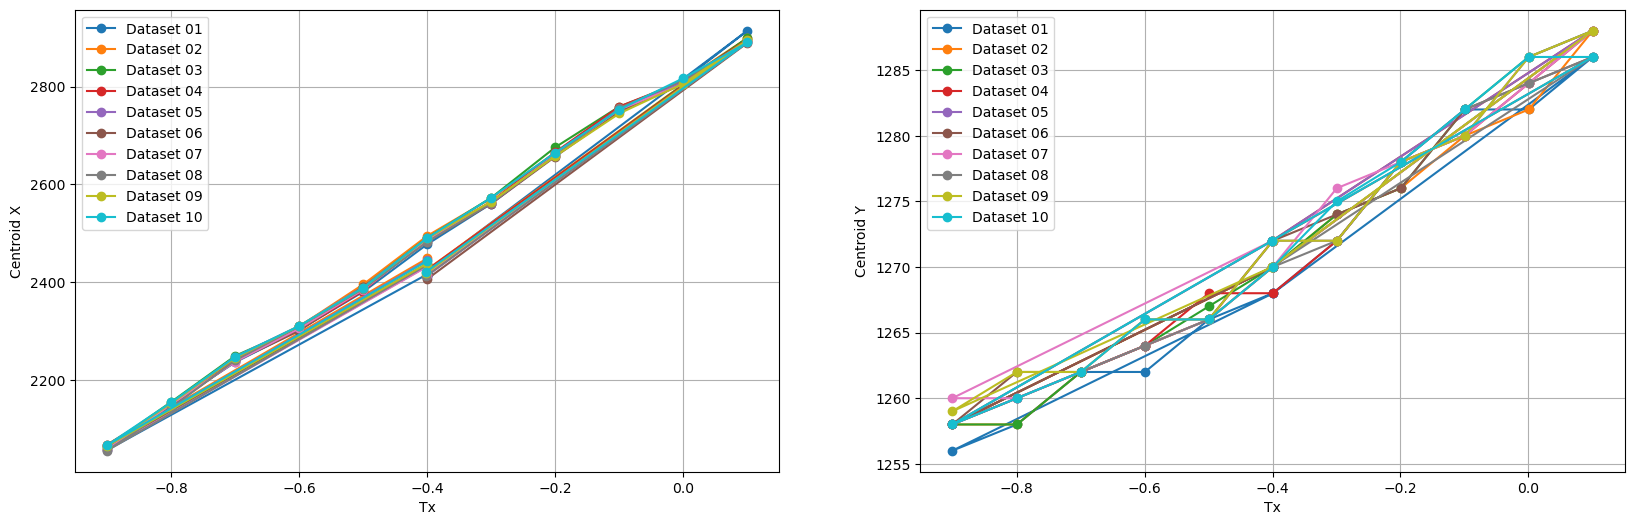

In [366]:
# observable = 'fwhm'
# observable = 'intensity'
observable = 'centroid'
# observable = 'photocollector'
# observable = 'z_pos'

pass_interval = (0, 10)
item_interval = (0, 13)

# Chose set interval of scans to plot.
first_pass, last_pass = pass_interval
sel_items = dict(list(data.items())[first_pass:last_pass+1])

if observable in ['intensity']:
    gr = 3
    labels = ['Peak', 'by mask', 'FWHM norm']
elif observable in ['centroid', 'fwhm']:
    gr = 2
    labels = ['X', 'Y']
else:
    gr = 1
    labels = ['X']

fr, upto = item_interval
scan_plot(sel_items, observable, first_item=fr, last_item=upto,
          gr=gr, labels=labels)

#### Statistics (avg, std dev, median) after a set of scans.

In [358]:
stats = observable_statistics(data, observable)


#### Show centroid following initial tx.

>>>>> Scan 0: Centroid raw at (cx=2417, cy=1268), 
>>>>> Scan 0: Centroid at (cx=2416, cy=1269), 
>>>>> Scan 1: Centroid raw at (cx=2057, cy=1256), 
>>>>> Scan 1: Centroid at (cx=2054, cy=1258), 
>>>>> Scan 2: Centroid raw at (cx=2151, cy=1258), 
>>>>> Scan 2: Centroid at (cx=2150, cy=1259), 
>>>>> Scan 3: Centroid raw at (cx=2237, cy=1262), 
>>>>> Scan 3: Centroid at (cx=2237, cy=1261), 
>>>>> Scan 4: Centroid raw at (cx=2303, cy=1262), 
>>>>> Scan 4: Centroid at (cx=2303, cy=1263), 
>>>>> Scan 5: Centroid raw at (cx=2381, cy=1266), 
>>>>> Scan 5: Centroid at (cx=2382, cy=1265), 
>>>>> Scan 6: Centroid raw at (cx=2478, cy=1268), 
>>>>> Scan 6: Centroid at (cx=2476, cy=1269), 
>>>>> Scan 7: Centroid raw at (cx=2561, cy=1272), 
>>>>> Scan 7: Centroid at (cx=2562, cy=1273), 
>>>>> Scan 8: Centroid raw at (cx=2663, cy=1278), 
>>>>> Scan 8: Centroid at (cx=2664, cy=1277), 
>>>>> Scan 9: Centroid raw at (cx=2749, cy=1282), 
>>>>> Scan 9: Centroid at (cx=2748, cy=1281), 
>>>>> Scan 10: Centr

/tmp/ipykernel_3585062/2002083889.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ctx_0.append(np.array([tx0, cx0]))
/tmp/ipykernel_3585062/2002083889.py:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ctx_m.append(np.array([txm, cxm]))
/tmp/ipykernel_3585062/2002083889.py:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ctx

>>>>> Scan 9: Centroid raw at (cx=2755, cy=1280), 
>>>>> Scan 9: Centroid at (cx=2755, cy=1281), 
>>>>> Scan 10: Centroid raw at (cx=2812, cy=1282), 
>>>>> Scan 10: Centroid at (cx=2815, cy=1284), 
>>>>> Scan 11: Centroid raw at (cx=2899, cy=1288), 
>>>>> Scan 11: Centroid at (cx=2902, cy=1287), 
>>>>> Scan 12: Centroid raw at (cx=2426, cy=1270), 
>>>>> Scan 12: Centroid at (cx=2426, cy=1269), 
>>>>> Scan 0: Centroid raw at (cx=2435, cy=1270), 
>>>>> Scan 0: Centroid at (cx=2437, cy=1269), 
>>>>> Scan 1: Centroid raw at (cx=2064, cy=1258), 
>>>>> Scan 1: Centroid at (cx=2066, cy=1257), 
>>>>> Scan 2: Centroid raw at (cx=2156, cy=1258), 
>>>>> Scan 2: Centroid at (cx=2154, cy=1259), 
>>>>> Scan 3: Centroid raw at (cx=2250, cy=1262), 
>>>>> Scan 3: Centroid at (cx=2249, cy=1261), 
>>>>> Scan 4: Centroid raw at (cx=2308, cy=1264), 
>>>>> Scan 4: Centroid at (cx=2309, cy=1263), 
>>>>> Scan 5: Centroid raw at (cx=2391, cy=1267), 
>>>>> Scan 5: Centroid at (cx=2388, cy=1267), 
>>>>> Scan 6: 

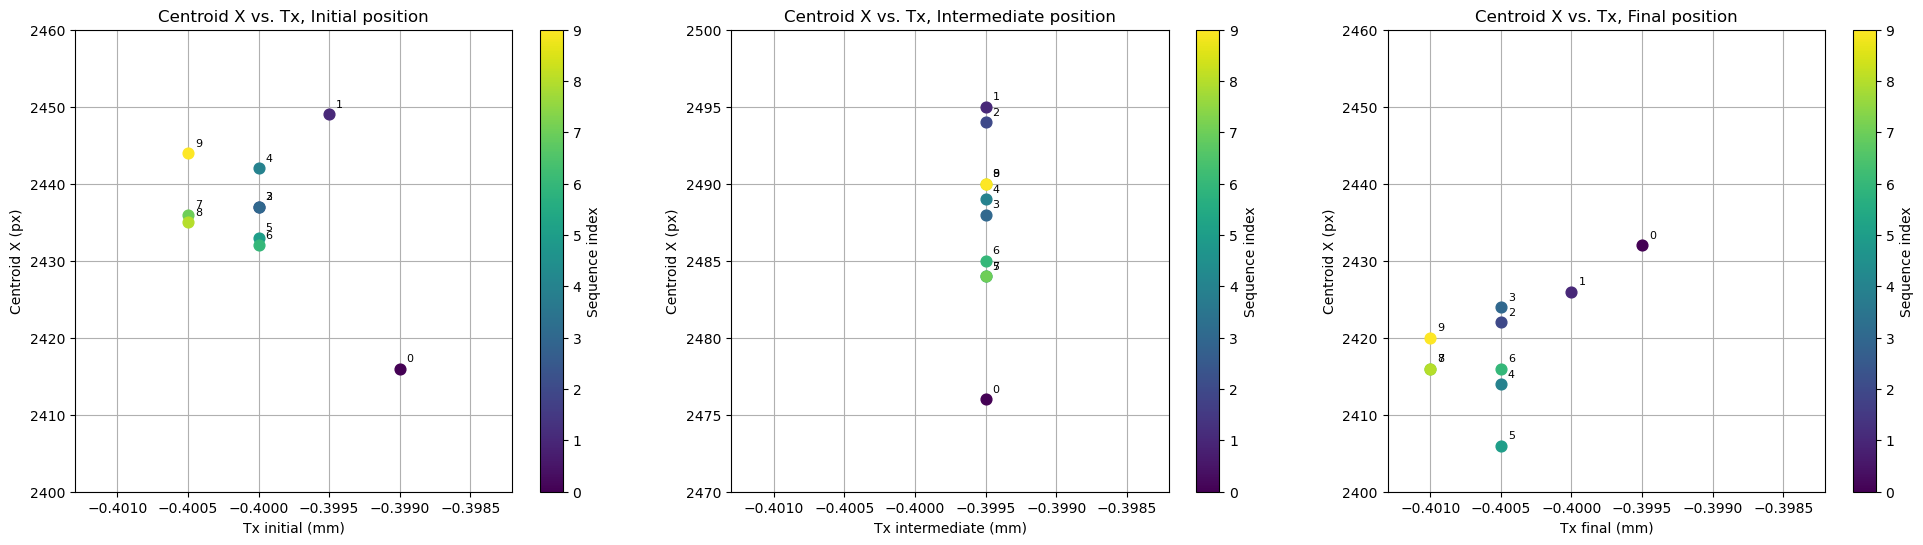

In [408]:
import matplotlib.cm as cm
import numpy as np

ctx_0 = []
ctx_m = []
ctx_f = []
npti = 0
nptf = 12

for dataset in data.values():
    bc  = beam_centroid(dataset, 'mirror.tx')
    tx0 = bc[npti][0]
    cx0 = bc[npti][1]
    ctx_0.append(np.array([tx0, cx0]))

    txm = bc[(npti + nptf) // 2][0]
    cxm = bc[(npti + nptf) // 2][1]
    ctx_m.append(np.array([txm, cxm]))

    txf = bc[nptf][0]
    cxf = bc[nptf][1]
    ctx_f.append(np.array([txf, cxf]))

ctx_0 = np.array(ctx_0)
ctx_m = np.array(ctx_m)
ctx_f = np.array(ctx_f)

n = len(ctx_0)
colors = cm.viridis(np.linspace(0, 1, n))

fig, (axx, axc, axy) = plt.subplots(1, 3, figsize=(24, 6))

for i, (tx, cx) in enumerate(ctx_0):
    axx.scatter(tx, cx[0], color=colors[i], zorder=3, s=60)
    axx.annotate(str(i), (tx, cx[0]), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (tx, cx) in enumerate(ctx_m):
    axc.scatter(tx, cx[0], color=colors[i], zorder=3, s=60)
    axc.annotate(str(i), (tx, cx[0]), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (tx, cx) in enumerate(ctx_f):
    axy.scatter(tx, cx[0], color=colors[i], zorder=3, s=60)
    axy.annotate(str(i), (tx, cx[0]), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)


sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=0, vmax=n - 1))
plt.colorbar(sm, ax=axx, label='Sequence index')
plt.colorbar(sm, ax=axc, label='Sequence index')
plt.colorbar(sm, ax=axy, label='Sequence index')

xmin, xmax = np.min(ctx_0[:, 0]) * 1.002, np.max(ctx_0[:, 0]) * 0.998

axx.grid(True)
axx.set_title("Centroid X vs. Tx, Initial position")
axx.set_xlabel('Tx initial (mm)')
axx.set_ylabel('Centroid X (px)')
axx.set_xlim(xmin, xmax)
axx.set_ylim(2400, 2460)

axc.grid(True)
axc.set_title("Centroid X vs. Tx, Intermediate position")
axc.set_xlabel('Tx intermediate (mm)')
axc.set_ylabel('Centroid X (px)')
axc.set_xlim(xmin, xmax)
axc.set_ylim(2470, 2500)
axc.grid(True)

axy.grid(True)
axy.set_title("Centroid X vs. Tx, Final position")
axy.set_xlabel('Tx final (mm)')
axy.set_ylabel('Centroid X (px)')
axy.set_xlim(xmin, xmax)
axy.set_ylim(2400, 2460)

plt.show()

>>>>> Scan 0: Centroid raw at (cx=2417, cy=1268), 
>>>>> Scan 0: Centroid at (cx=2418, cy=1269), 
>>>>> Scan 1: Centroid raw at (cx=2057, cy=1256), 
>>>>> Scan 1: Centroid at (cx=2057, cy=1258), 
>>>>> Scan 2: Centroid raw at (cx=2151, cy=1258), 
>>>>> Scan 2: Centroid at (cx=2150, cy=1259), 
>>>>> Scan 3: Centroid raw at (cx=2237, cy=1262), 
>>>>> Scan 3: Centroid at (cx=2236, cy=1261), 
>>>>> Scan 4: Centroid raw at (cx=2303, cy=1262), 
>>>>> Scan 4: Centroid at (cx=2302, cy=1263), 
>>>>> Scan 5: Centroid raw at (cx=2381, cy=1266), 
>>>>> Scan 5: Centroid at (cx=2382, cy=1265), 
>>>>> Scan 6: Centroid raw at (cx=2478, cy=1268), 
>>>>> Scan 6: Centroid at (cx=2478, cy=1269), 
>>>>> Scan 7: Centroid raw at (cx=2561, cy=1272), 
>>>>> Scan 7: Centroid at (cx=2561, cy=1273), 
>>>>> Scan 8: Centroid raw at (cx=2663, cy=1278), 
>>>>> Scan 8: Centroid at (cx=2664, cy=1277), 
>>>>> Scan 9: Centroid raw at (cx=2749, cy=1282), 
>>>>> Scan 9: Centroid at (cx=2748, cy=1280), 
>>>>> Scan 10: Centr

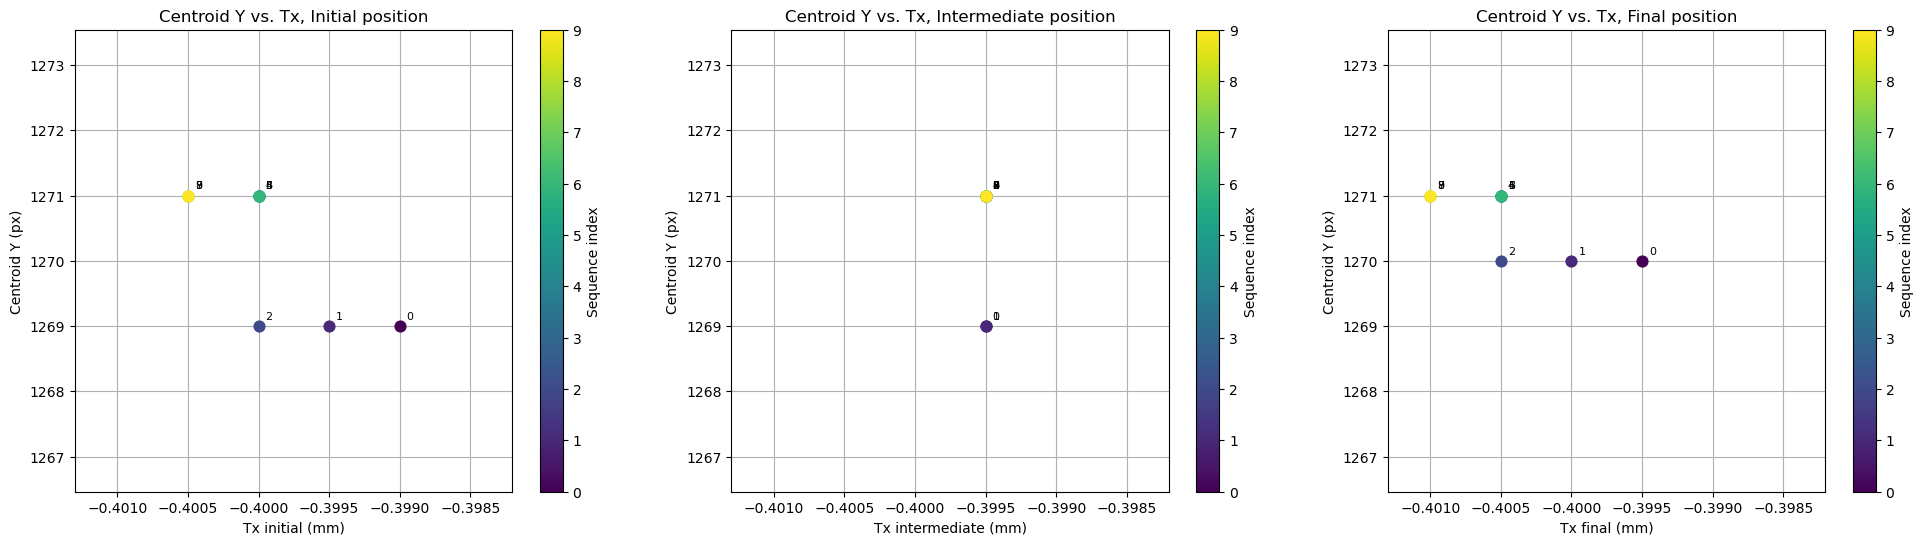

In [411]:
import matplotlib.cm as cm
import numpy as np

cty_0 = []
cty_m = []
cty_f = []
npti = 0
nptf = 12

for dataset in data.values():
    bc  = beam_centroid(dataset, 'mirror.tx')
    tx0 = bc[npti][0]
    cy0 = bc[npti][1]
    cty_0.append(np.array([tx0, cy0[1]]))

    txm = bc[(npti + nptf) // 2][0]
    cym = bc[(npti + nptf) // 2][1]
    cty_m.append(np.array([txm, cym[1]]))

    txf = bc[nptf][0]
    cyf = bc[nptf][1]
    cty_f.append(np.array([txf, cyf[1]]))

cty_0 = np.array(cty_0)
cty_m = np.array(cty_m)
cty_f = np.array(cty_f)

n = len(cty_0)
colors = cm.viridis(np.linspace(0, 1, n))

fig, (axx, axc, axy) = plt.subplots(1, 3, figsize=(24, 6))

for i, (tx, cy) in enumerate(cty_0):
    axx.scatter(tx, cy, color=colors[i], zorder=3, s=60)
    axx.annotate(str(i), (tx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (tx, cy) in enumerate(cty_m):
    axc.scatter(tx, cy, color=colors[i], zorder=3, s=60)
    axc.annotate(str(i), (tx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (tx, cy) in enumerate(cty_f):
    axy.scatter(tx, cy, color=colors[i], zorder=3, s=60)
    axy.annotate(str(i), (tx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)


sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=0, vmax=n - 1))
plt.colorbar(sm, ax=axx, label='Sequence index')
plt.colorbar(sm, ax=axc, label='Sequence index')
plt.colorbar(sm, ax=axy, label='Sequence index')

xmin, xmax = np.min(cty_0[:, 0]) * 1.002, np.max(cty_0[:, 0]) * 0.998
ymin, ymax = np.min(cty_0[:, 1]) * 0.998, np.max(cty_0[:, 1]) * 1.002

axx.grid(True)
axx.set_title("Centroid Y vs. Tx, Initial position")
axx.set_xlabel('Tx initial (mm)')
axx.set_ylabel('Centroid Y (px)')
axx.set_xlim(xmin, xmax)
axx.set_ylim(ymin, ymax)

axc.grid(True)
axc.set_title("Centroid Y vs. Tx, Intermediate position")
axc.set_xlabel('Tx intermediate (mm)')
axc.set_ylabel('Centroid Y (px)')
axc.set_xlim(xmin, xmax)
axc.set_ylim(ymin, ymax)
axc.grid(True)

axy.grid(True)
axy.set_title("Centroid Y vs. Tx, Final position")
axy.set_xlabel('Tx final (mm)')
axy.set_ylabel('Centroid Y (px)')
axy.set_xlim(xmin, xmax)
axy.set_ylim(ymin, ymax)

plt.show()

Raw centroid: (2435, 1270),
 Smoothed centroid: (2436, 1272)
FWHM X (raw): 176 pixels, FWHM Y (raw): 89 pixels
FWHM X: 176 pixels, FWHM Y: 89 pixels


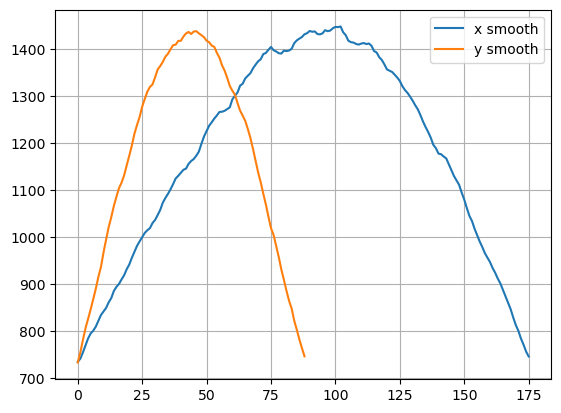

In [333]:
import numpy as np
from scipy.signal import savgol_filter

img = data['01']['scan-0012']['dvf_B1']['data']
cx = np.sum(img, axis=0).argmax()
cy = np.sum(img, axis=1).argmax()

# FWHMs
x_profile = img[cy, :]
y_profile = img[:, cx]

halfx = x_profile.max() / 2
halfy = y_profile.max() / 2


xsmooth = savgol_filter(x_profile, window_length=13, polyorder=2)
ysmooth = savgol_filter(y_profile, window_length=13, polyorder=2)

xmaxraw = np.argmax(x_profile)
ymaxraw = np.argmax(y_profile)
xmax = np.argmax(xsmooth)
ymax = np.argmax(ysmooth)

print(f"Raw centroid: ({xmaxraw}, {ymaxraw}),\n"
      f" Smoothed centroid: ({xmax}, {ymax})")

fwhm_x_raw = np.sum(x_profile > halfx)
fwhm_y_raw = np.sum(y_profile > halfy)
fwhm_x = np.sum(xsmooth > halfx)
fwhm_y = np.sum(ysmooth > halfy)

print(f"FWHM X (raw): {fwhm_x_raw} pixels, FWHM Y (raw): {fwhm_y_raw} pixels")
print(f"FWHM X: {fwhm_x} pixels, FWHM Y: {fwhm_y} pixels")


# plt.plot(x_profile[x_profile > halfx], label='x')
# plt.plot(y_profile[y_profile > halfy], label='y')
plt.plot(xsmooth[xsmooth > halfx], label='x smooth')
plt.plot(ysmooth[ysmooth > halfy], label='y smooth')
# plt.plot([0, len(x_profile)],
#          [x_profile.max() / 2, x_profile.max() / 2],
#          'k--', label='Half max')
plt.grid(True)
plt.legend()


In [315]:
np.sum(x_profile > (x_profile.max() / 2))

176

In [267]:
tx00 = []
tx01 = []
tx11 = []
tx12 = []
nset = []
for key, dataset in data.items():
    tx00.append(dataset['scan-0000']['attrs']['mirror.tx'][0])
    tx01.append(dataset['scan-0001']['attrs']['mirror.tx'][0])
    tx11.append(dataset['scan-0011']['attrs']['mirror.tx'][0])
    tx12.append(dataset['scan-0012']['attrs']['mirror.tx'][0])
    nset.append(int(key))

for k in nset:
    n = k - 1
    print(f"{n}: {tx00[n]}, {tx01[n]}, {tx11[n]}, {tx12[n]}")


0: -0.399, -0.9005, 0.1005, -0.3995
1: -0.3995, -0.9005, 0.1005, -0.4
2: -0.4, -0.9005, 0.1005, -0.4005
3: -0.4, -0.9005, 0.1005, -0.4005
4: -0.4, -0.9005, 0.1005, -0.4005
5: -0.4, -0.9005, 0.1005, -0.4005
6: -0.4, -0.9005, 0.1005, -0.4005
7: -0.4005, -0.9005, 0.1005, -0.401
8: -0.4005, -0.9005, 0.1005, -0.401
9: -0.4005, -0.9005, 0.1005, -0.401


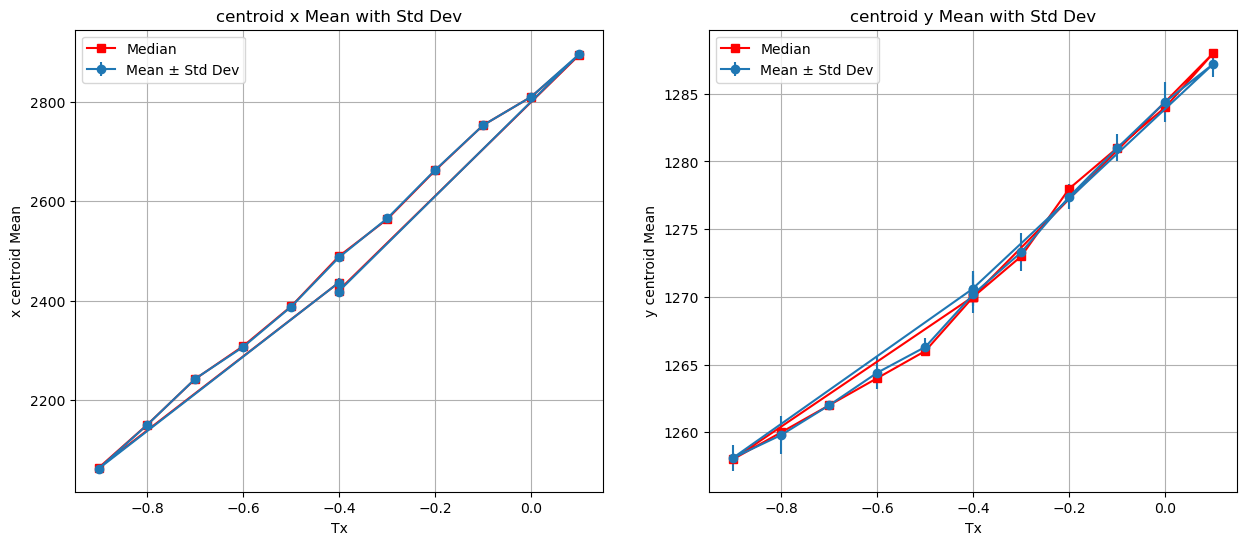

In [268]:
tx = stats['xval']
cx = stats['mean'][0]
cy = stats['mean'][1]
dx = stats['std_dev'][0]
dy = stats['std_dev'][1]
mx = stats['median'][0]
my = stats['median'][1]

fig, (axmx, axmy) = plt.subplots(1, 2, figsize=(15, 6))

axmx.errorbar(tx, cx, yerr=dx, fmt='o-', label='Mean ± Std Dev')
axmx.set_ylabel(f'x {observable} Mean')
axmx.set_title(f'{observable} x Mean with Std Dev')

axmy.errorbar(tx, cy, yerr=dy, fmt='o-', label='Mean ± Std Dev')
axmy.set_ylabel(f'y {observable} Mean')
axmy.set_title(f'{observable} y Mean with Std Dev')

axmx.plot(tx, mx, 's-', label='Median', color='red')
# axmx.set_ylabel(f'x {observable} Median')
# axmx.set_title(f'{observable} x Median')

axmy.plot(tx, my, 's-', label='Median', color='red')
# axmy.set_ylabel(f'y {observable} Median')
# axmy.set_title(f'{observable} y Median')

for ax in [axmx, axmy]:
    ax.grid(True)
    ax.set_xlabel('Tx')
    ax.legend()
    ax.grid(True)

### Sequence of beam images.

In [ ]:
# Working directory for saving the plots.
wdir = "/home/ABTLUS/arnaldo.filho/Beam_profiling/beam_profiles"

# Plot centroids and images for all datasets.
for scanpass, dataset in data.items():
    centroid_plot(dataset, scanpass, wdir=wdir, save_fmt='')


In [219]:
import numpy as np

pixsize = 0.48  # um/px

initfindiff = []
scandiff = []
for scanpass, dataset in data.items():
    print(f"\n##### Scan pass: {scanpass}")

    cent = observable_data(dataset, 'centroid')
    tx = cent[2][1:-1] * pixsize
    cx = cent[3][0][1:-1] * pixsize

    a, b = np.polyfit(tx, cx, 1)
    cxfit = a * tx + b
    c0a = cent[3][0][0] * pixsize
    c0b = cent[3][0][-1] * pixsize
    c0x = cx[len(cx) // 2]

    c0fit = a * tx[len(tx) // 2] + b

    print("Linear fit parameters:"
          f"               a = {a:.4f}, b = {b:.4f}")
    print("Initial and final centroid values:"
          f"   {c0a:.2f} → {c0b:.2f}")
    print("Central centroid value along scan:"
          f"   {c0x:.2f}")

    dinfin = (c0b / c0a - 1) * 100
    cdiff  = (c0x / c0a - 1) * 100
    scandiff.append(cdiff)
    initfindiff.append(dinfin)
    print("Centroid differences, relative to initial position:")
    print(f"\t at center, along scan:   {(c0x - c0a) / c0a * 100 :.2f}%")
    print(f"\t after scan:              {dinfin:.2f}%")
    print(f"\t at center, based on fit: {(c0fit - c0a) / c0a * 100 :.2f}%")

scandiff = np.array(scandiff)
initfindiff = np.array(initfindiff)


##### Scan pass: 01
Linear fit parameters:               a = 851.3394, b = 1354.8682
Initial and final centroid values:   1160.16 → 1163.52
Central centroid value along scan:   1189.44
Centroid differences, relative to initial position:
	 at center, along scan:   2.52%
	 after scan:              0.29%
	 at center, based on fit: 2.71%

##### Scan pass: 02
Linear fit parameters:               a = 838.0736, b = 1354.8983
Initial and final centroid values:   1175.52 → 1164.48
Central centroid value along scan:   1197.60
Centroid differences, relative to initial position:
	 at center, along scan:   1.88%
	 after scan:              -0.94%
	 at center, based on fit: 1.59%

##### Scan pass: 03
Linear fit parameters:               a = 838.8955, b = 1355.4923
Initial and final centroid values:   1168.80 → 1162.56
Central centroid value along scan:   1195.68
Centroid differences, relative to initial position:
	 at center, along scan:   2.30%
	 after scan:              -0.53%
	 at center, based o

In [227]:
def correlate(a, b):
    """Calculate the normalized cross-correlation between two 1D arrays."""
    a = a - np.mean(a)
    b = b - np.mean(b)
    norm = np.std(a) * np.std(b) * len(a)
    return np.correlate(a, b, mode='full') / norm


Correlation coefficient between initial/final change and scan change: 0.9042
Best correlation: 0.9042273892087485
Shift needed: 0 indices
 Initial/final mean and std. deviation values: -0.7377 ± 0.4110
 Scan/initial mean and std. deviation values: 2.1020 ± 0.1974


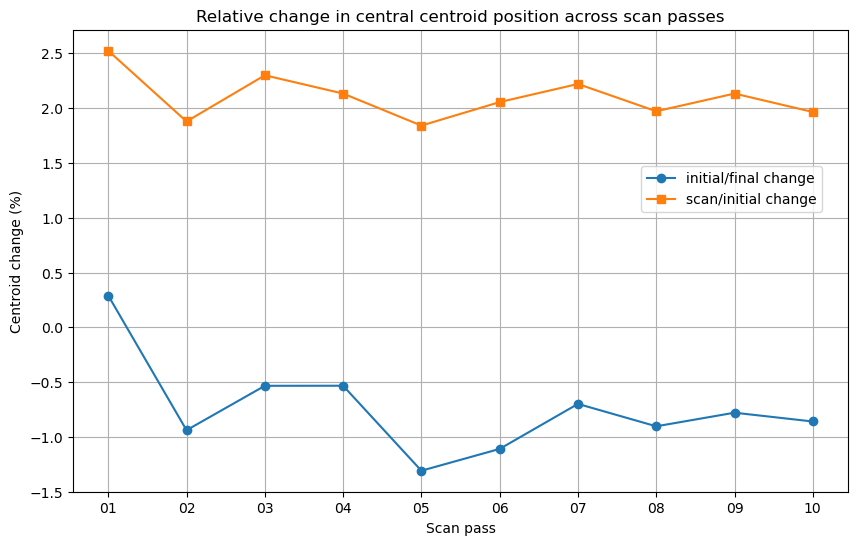

In [341]:
ifdiff = np.array(initfindiff)    # - np.mean(initfindiff)
sdiff  = np.array(scandiff)       # - np.mean(scandiff)

corr_mat = np.corrcoef(sdiff, ifdiff)
print("\nCorrelation coefficient between"
      f" initial/final change and scan change: {corr_mat[0, 1]:.4f}")

# cross_correlation = np.correlate(sdiff, ifdiff, mode='same')
cc = correlate(sdiff, ifdiff)
lags = np.arange(-len(sdiff) + 1, len(sdiff))
best_lag = lags[np.argmax(cc)]
print(f"Best correlation: {np.max(cc)}")
print(f"Shift needed: {best_lag} indices")


# print("Cross-correlation between initial/final change and scan change:"
#       f" {cross_correlation}")

fig, ax = plt.subplots(figsize=(10, 6))
sc = np.array(list(data.keys()))
ax.plot(sc, ifdiff, marker='o', label='initial/final change')
ax.plot(sc, sdiff, marker='s', label='scan/initial change')
# ax.plot(sc, cc, marker='^',
#         label='cross-correlation (normalized)')
ax.grid(True)
# ax.set_ylim(0, max(max(ifdiff), max(sdiff)) * 1.2)
ax.set_xlabel('Scan pass')
ax.set_ylabel('Centroid change (%)')
ax.legend(loc='upper center', bbox_to_anchor=(0.85, 0.72))
ax.set_title('Relative change in central centroid position across scan passes')

print(" Initial/final mean and std. deviation values:"
      f" {np.mean(ifdiff):.4f} ± {np.std(ifdiff):.4f}")
print(" Scan/initial mean and std. deviation values:"
      f" {np.mean(sdiff):.4f} ± {np.std(sdiff):.4f}")

plt.show()

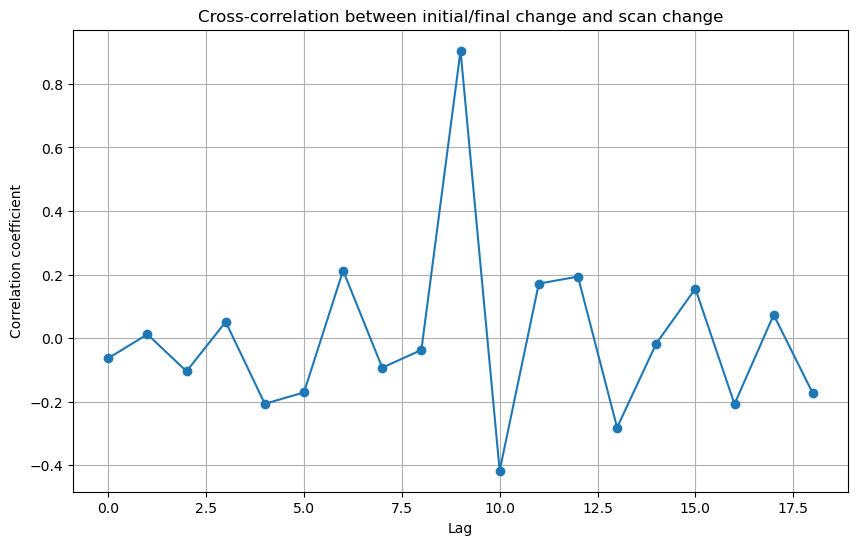

0.9042273892087485


In [340]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cc, marker='o', label='initial/final change')
ax.grid(True)
ax.set_title("Cross-correlation between initial/final change and scan change")
ax.set_xlabel('Lag')
ax.set_ylabel('Correlation coefficient')
# ax.legend()
plt.show()
print(np.max(cc))

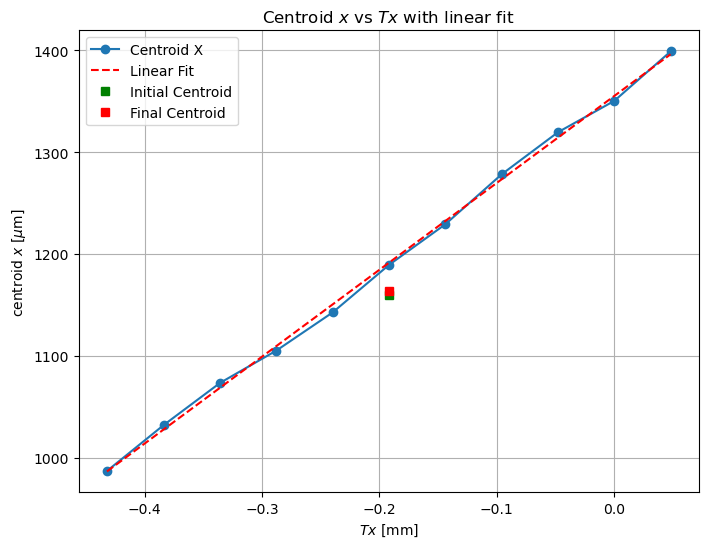

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))

dataset = data['01']
cent = observable_data(dataset, 'centroid')
tx = cent[2][1:-1] * pixsize
cx = cent[3][0][1:-1] * pixsize

a, b = np.polyfit(tx, cx, 1)
cxfit = a * tx + b
c0a = cent[3][0][0] * pixsize
c0b = cent[3][0][-1] * pixsize
# c0x = cx[len(cx) // 2]

c0fit = a * tx[len(tx) // 2] + b

ax.plot(tx, cx, 'o-', label='Centroid X')
ax.plot(tx, cxfit, 'r--', label='Linear Fit')
ax.plot(cent[2][0] * pixsize, c0a, 'gs', label='Initial Centroid')
ax.plot(cent[2][-1] * pixsize, c0b, 'rs', label='Final Centroid')
ax.set_xlabel(r'$Tx$ [mm]')
ax.set_ylabel(r'centroid $x$ [$\mu$m]')
ax.set_title(r'Centroid $x$ vs $Tx$ with linear fit')
ax.legend()
ax.grid(True)

#### Test with a specific scan frame.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dx = 4
threshold = 10
dataset = data['03']
scandata = '0004'

img = dataset[f'scan-{scandata}']['dvf_B1']['data']
centroid = beam_centroid(dataset, 'mirror.tx')
tx, (cx, cy) = centroid[int(scandata)]

roi_avg = np.mean(img[cy-dx:cy+dx, cx-dx:cx+dx])
mean = np.mean(img)
ratio_rtom = roi_avg / mean

print(f"ROI average: {roi_avg:.2f}, Mean: {mean:.2f},"
      f" Ratio (ROI/Mean): {ratio_rtom:.2f}")

print(tx, cx, cy)
plt.imshow(img)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

img1 = data['03']['scan-0000']['dvf_A1']['data']
img2 = data['03']['scan-0000']['dvf_B1']['data']

cx = np.sum(img2, axis=0).argmax()
cy = np.sum(img2, axis=1).argmax()

ax1.imshow(img1, cmap='viridis')
ax1.set_title('dvf_A1')

ax2.imshow(img2, cmap='viridis')
ax2.set_title('dvf_B1')

print(f"Centroid (dvf_B1): {cx}, {cy}")